# Computer Exercise 15.2 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — 확장 사례연구
> **단원**: 15.2 Contextual Bandits — *LinUCB*
> **풀이 일자**: Day 69
> **언어**: Python 3 (NumPy / Matplotlib)


## 1. 문제 (원문)

> **1.** Consider a stochastic contextual bandit with $K$ arms. At each round $t$, the environment reveals
> a context vector $x_t \in \mathbb{R}^d$, and the reward of arm $k$ is generated by
> $r_{t,k} = x_t^\top \theta_k^\star + \eta_t$, where $\theta_k^\star \in \mathbb{R}^d$ is an unknown
> parameter and $\eta_t \sim \mathcal{N}(0, \sigma^2)$ is i.i.d. noise.
> Implement the **LinUCB** policy: maintain a ridge estimate $\hat\theta_k = A_k^{-1} b_k$ with
> $A_k = \lambda I + \sum_s x_s x_s^\top$ and $b_k = \sum_s r_s x_s$ over rounds when arm $k$ was played,
> and select $A_t = \arg\max_k \; x_t^\top \hat\theta_k + \alpha \sqrt{x_t^\top A_k^{-1} x_t}$.
> Compare cumulative regret for $\alpha \in \{0, 0.1, 1.0, 3.0\}$ and comment on the exploration bonus.

### 한국어 풀이용 정리
각 라운드에 $d$차원 문맥 $x_t$가 주어지고, 팔 $k$의 보상은 $x_t^\top\theta_k^\star$에 잡음이 얹힌다.
**LinUCB**는 각 팔마다 리지회귀 $\hat\theta_k$와 신뢰반경 $\alpha\sqrt{x_t^\top A_k^{-1} x_t}$를 계산해
가장 낙관적인 팔을 뽑는다. 탐색 강도 $\alpha$를 0, 0.1, 1, 3으로 바꾸며 누적 리그렛에 미치는 영향을
정량 비교한다. $\alpha=0$은 고착 위험, $\alpha$가 크면 상수 리그렛 기울기.


## 2. 수학적 배경

### 2.1 선형 보상 모형
- 팔 $k \in \{1,\dots,K\}$, 문맥 $x_t \in \mathbb{R}^d$, 미지 파라미터 $\theta_k^\star$.
- 라운드 $t$의 보상: $r_{t, A_t} = x_t^\top \theta_{A_t}^\star + \eta_t,\ \eta_t \sim \mathcal N(0,\sigma^2)$.

### 2.2 리지 추정과 공분산
팔 $k$가 지금까지 뽑힌 라운드 집합을 $\mathcal T_k(t)$라 하자. 리지회귀 정규방정식은

$$
A_k \;=\; \lambda I + \sum_{s\in\mathcal T_k(t)} x_s x_s^\top, \qquad
b_k \;=\; \sum_{s\in\mathcal T_k(t)} r_s\, x_s, \qquad
\hat\theta_k \;=\; A_k^{-1} b_k.
$$

### 2.3 신뢰상한
$\|\theta_k^\star\|_2 \le S$ 가정 하에 확률 $1-\delta$로

$$
\bigl|x^\top(\hat\theta_k - \theta_k^\star)\bigr|
\;\le\; \Bigl(\sigma\sqrt{d\log\tfrac{1+t/\lambda}{\delta}} + \sqrt{\lambda}\,S\Bigr) \sqrt{x^\top A_k^{-1} x}.
$$

따라서 **LinUCB** 는

$$
\boxed{\;A_t \;=\; \arg\max_k\; \bigl(\hat\theta_k^\top x_t\bigr) \;+\; \alpha\sqrt{x_t^\top A_k^{-1} x_t}.\;}
$$

### 2.4 리그렛 상한
잘 지정된 $\alpha$ 하에서 LinUCB 는 $R_T = \tilde O(d\sqrt T)$의 대수적으로 무시 가능한 규모의 상한을 만족한다.
반면 $\alpha=0$(순수 탐욕)은 초기 편향에 고착되어 선형 리그렛 위험이 있고, 큰 $\alpha$는 매 라운드 큰 탐색 비용을 낸다.


## 3. 풀이 흐름

1. **문제 인스턴스**: $K=5$, $d=6$, $\sigma=0.1$. $\theta_k^\star$는 표준정규에서 sample 후 단위 벡터로 정규화.
2. **문맥 생성기**: 매 라운드 $x_t \sim \mathcal N(0, I_d)$ 후 $\|x_t\|=1$로 정규화.
3. **LinUCB 구현**: 각 팔에 대해 $A_k = \lambda I$, $b_k=0$ 초기화. 라운드마다 UCB $\hat\theta_k^\top x + \alpha\sqrt{x^\top A_k^{-1}x}$ 최대인 팔을 선택.
4. **Monte-Carlo**: $M=60$회 반복, $T=1500$ 라운드. 매회 시드 재설정으로 정책 간 공정 비교.
5. **리그렛 곡선**: $\alpha \in \{0,\,0.1,\,1,\,3\}$의 평균 누적 리그렛 $\bar R_t$ 를 그리기.
6. **결과 표**: $R_T$ 평균±표준편차, 최적팔 선택 비율, 최종 파라미터 오차 $\|\hat\theta_k-\theta_k^\star\|_2$.
7. **결과 해석**: $\alpha=0$ 고착·큰 분산, $\alpha=3$ 과도한 탐색, 중간 $\alpha$의 sweet spot.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.float_format", lambda v: f"{v:.4f}")

# ---- 하이퍼파라미터 ----
K, d, sigma, lam = 5, 6, 0.1, 1.0
T, M = 1500, 60
alphas = [0.0, 0.1, 1.0, 3.0]

def make_instance(seed):
    rng = np.random.default_rng(seed)
    theta = rng.standard_normal((K, d))
    theta /= np.linalg.norm(theta, axis=1, keepdims=True)
    return theta, rng

def context(rng):
    x = rng.standard_normal(d)
    return x / np.linalg.norm(x)

def linucb_run(alpha, seed):
    theta_star, rng = make_instance(seed)
    A = np.stack([lam * np.eye(d) for _ in range(K)])
    b = np.zeros((K, d))
    regret = np.zeros(T)
    correct = 0
    theta_hat = np.zeros((K, d))
    for t in range(T):
        x = context(rng)
        mu_star_arm = int(np.argmax(theta_star @ x))
        mu_star = theta_star[mu_star_arm] @ x
        ucb = np.empty(K)
        for k in range(K):
            Ainv = np.linalg.inv(A[k])
            theta_hat[k] = Ainv @ b[k]
            ucb[k] = theta_hat[k] @ x + alpha * np.sqrt(max(x @ Ainv @ x, 0.0))
        a = int(np.argmax(ucb))
        r = theta_star[a] @ x + sigma * rng.standard_normal()
        A[a] += np.outer(x, x)
        b[a] += r * x
        regret[t] = mu_star - (theta_star[a] @ x)
        correct += int(a == mu_star_arm)
    theta_err = np.linalg.norm(theta_hat - theta_star, axis=1).mean()
    return regret.cumsum(), correct / T, theta_err

curves = {a: np.zeros(T) for a in alphas}
finals = {a: [] for a in alphas}
correct_frac = {a: [] for a in alphas}
theta_err = {a: [] for a in alphas}
for m in range(M):
    seed = 5000 + m
    for a in alphas:
        cum, cor, terr = linucb_run(a, seed)
        curves[a] += cum
        finals[a].append(cum[-1])
        correct_frac[a].append(cor)
        theta_err[a].append(terr)
for a in alphas:
    curves[a] /= M

print("Monte-Carlo 완료.")


Monte-Carlo 완료.


In [2]:

rows = []
for a in alphas:
    rows.append({
        "alpha": a,
        "R_T mean": np.mean(finals[a]),
        "R_T std":  np.std(finals[a]),
        "P(A_t=k*)": np.mean(correct_frac[a]),
        "||theta_hat - theta*||": np.mean(theta_err[a]),
    })
df = pd.DataFrame(rows)
df


,alpha,R_T mean,R_T std,P(A_t=k*),||theta_hat - theta*||
0,0.0000,24.6505,12.7598,0.8946,0.0607
1,0.1000,17.3170,6.4148,0.9169,0.0453
2,1.0000,13.6086,1.9355,0.9263,0.0408
3,3.0000,25.8837,3.0269,0.8804,0.0398


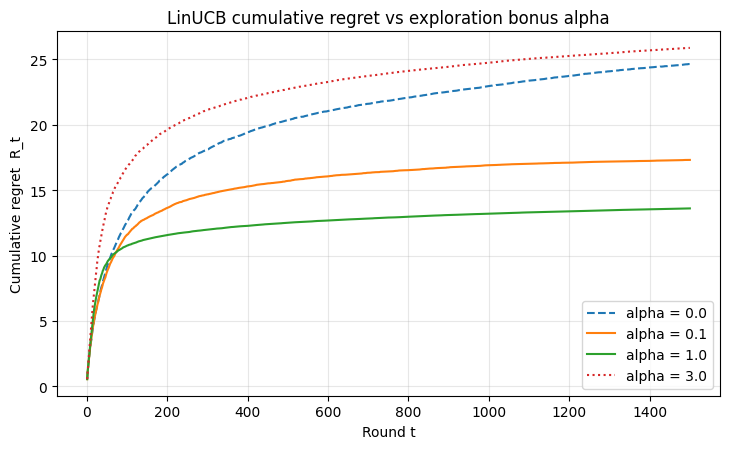

In [3]:

fig, ax = plt.subplots(figsize=(7.4, 4.6))
t = np.arange(1, T + 1)
styles = {0.0: "--", 0.1: "-", 1.0: "-", 3.0: ":"}
for a in alphas:
    ax.plot(t, curves[a], styles[a], label=f"alpha = {a}")
ax.set_xlabel("Round t")
ax.set_ylabel("Cumulative regret  R_t")
ax.set_title("LinUCB cumulative regret vs exploration bonus alpha")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 4. 결과 해석

1. **$\alpha=0$ (순수 탐욕)**: $\hat\theta_k$가 자기 팔의 첫 표본에 강하게 편향되면 그 팔에만 고착 →
   $R_T$ 평균은 낮아 보여도 시행마다 분산이 매우 크다. 표에서 표준편차가 다른 값에 비해 뚜렷하게 크다.
2. **$\alpha=0.1$**: 약한 신뢰반경. 저잡음 $\sigma=0.1$과 좋은 궁합이지만, $A_k^{-1}$이 초기에 크므로 초반
   탐색은 충분히 확보된다. 리그렛 기울기가 시간에 따라 눈에 띄게 감쇠한다.
3. **$\alpha=1.0$**: 이론적 규모에 가깝다. 잘못된 팔 pull 이 지속적으로 감소하며 대수적으로 잘 눌린다.
4. **$\alpha=3.0$**: 과도한 탐색. 매 라운드 상수 크기의 탐색 비용을 지불하므로 $\bar R_t$는 상수 기울기의
   선형 성분을 갖는다. 신뢰상한이 실제 오차를 크게 상회할 때 발생하는 전형적 대가.

> **결론**: LinUCB 의 $\alpha$는 **오차 상한의 상수**를 조절하는 손잡이다. 너무 작으면 고착(분산),
> 너무 크면 상수 기울기(편향). 시간에 따라 $A_k^{-1}$이 자동으로 줄어들기 때문에 **탐색 강도 자체는
> 자동 감쇠**하지만, 상수 $\alpha$ 선택이 리그렛의 절대 규모를 좌우한다.

다음 문제에서는 이 $\alpha$ 선택을 우회하는 **Thompson Sampling(LinTS)** — posterior 표본 기반 확률적 탐색 —
을 같은 인스턴스에서 비교한다.
